In [ ]:
#AdaBosst vs Gradient Boosting on the Digits Dataset
#Code Availability
#The code for this project is available at:
#https://github.com/Lojana96/boosting-tutorial-digits-classification

In [2]:
#01. Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
# Create clear plots

plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
#02. Load the Digits Dataset

# The Digits Dataset contains 8*8 images of handwritten digits (0-9).
data = load_digits()

# Features and target
X = data.data
y = data.target

# Put into a DataFrame for easier viewing
df = pd.DataFrame(X)
df["target"] = y

# Show first 5 rows
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]



Dataset shape: (1797, 65)
Number of samples: 1797
Number of features: 64

Target labels: [0 1 2 3 4 5 6 7 8 9]
Class distribution:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Missing values in dataset: 0


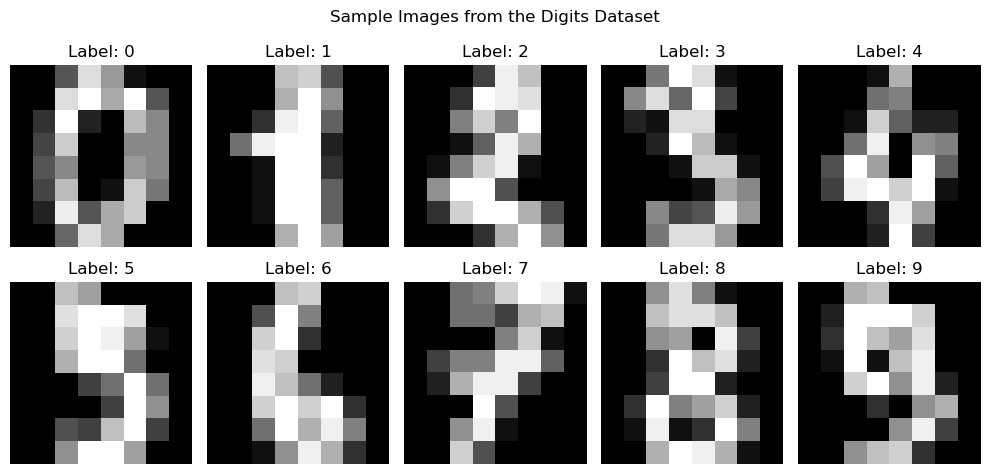

In [5]:
#03. Explore the Data set

print("\nDataset shape:", df.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget labels:", data.target_names)
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())

print("\nMissing values in dataset:", df.isnull().sum().sum())

#Display a few sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(data.images[i], cmap="gray")
    ax.set_title(f"Label: {data.target[i]}")
    ax.axis("off")

plt.suptitle("Sample Images from the Digits Dataset")
plt.tight_layout()
plt.show()


In [6]:
#04.Split the dataset

# Use stratify=y to preserve class proportions in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1437, 64)
Testing set shape: (360, 64)


In [7]:
#05. Train a weak Learner

# A decision stump is a decision tree with max_depth=1.
# This is used as a simple baseline model.
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)
weak_learner.fit(X_train, y_train)

# Predict on test data
y_pred_weak = weak_learner.predict(X_test)


In [8]:
#06. Train the AdaBoost model

# AdaBoost commonly uses decision stumps as weak learners.
base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)

try:
    adaboost_model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    )
except TypeError:
    adaboost_model = AdaBoostClassifier(
        base_estimator=base_tree,
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    )

adaboost_model.fit(X_train, y_train)
y_pred_ada = adaboost_model.predict(X_test)


In [9]:
#07. Train the Gradient Boosting model

# GradientBoostingClassifier uses shallow trees by default-style settings;
# for gradientBoosting  max_depth=3 is a common practical choice.
#To make the comparison more balanced, max_dept is set to 1 (max_dept=1)
gradient_boost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=1,
    random_state=42
)

gradient_boost_model.fit(X_train, y_train)
y_pred_gb = gradient_boost_model.predict(X_test)


In [10]:
#08. Define an evaluation function

# For multiclass classification, weighted averaging is appropriate
# because it accounts for class frequency across all 10 classes.
def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a classification model using common metrics.
    Returns a dictionary of results.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'=' * 50}")
    print(f"Model: {model_name}")
    print(f"{'=' * 50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }


In [11]:
#09. Evaluate all models

results = []

results.append(evaluate_model("Weak Learner (Decision Stump)", y_test, y_pred_weak))
results.append(evaluate_model("AdaBoost", y_test, y_pred_ada))
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))



Model: Weak Learner (Decision Stump)
Accuracy : 0.1944
Precision: 0.0705
Recall   : 0.1944
F1-score : 0.0936

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.94      0.72        36
           1       0.12      1.00      0.21        36
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        37
           4       0.00      0.00      0.00        36
           5       0.00      0.00      0.00        37
           6       0.00      0.00      0.00        36
           7       0.00      0.00      0.00        36
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00        36

    accuracy                           0.19       360
   macro avg       0.07      0.19      0.09       360
weighted avg       0.07      0.19      0.09       360


Model: AdaBoost
Accuracy : 0.8306
Precision: 0.8367
Recall   : 0.8306
F1-score : 0.8291

Classification R

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
#10. Create a results table

results_df = pd.DataFrame(results)

# Round for neat display
results_df_rounded = results_df.copy()
results_df_rounded[["Accuracy", "Precision", "Recall", "F1-score"]] = results_df_rounded[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

print("\nFinal Metric Table:")
print(results_df_rounded)



Final Metric Table:
                           Model  Accuracy  Precision  Recall  F1-score
0  Weak Learner (Decision Stump)    0.1944     0.0705  0.1944    0.0936
1                       AdaBoost    0.8306     0.8367  0.8306    0.8291
2              Gradient Boosting    0.9139     0.9136  0.9139    0.9132


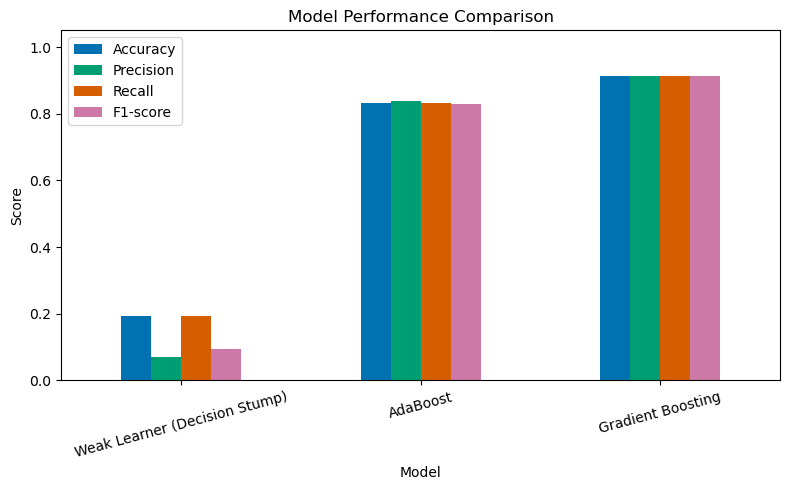

In [13]:
#11. Plot model performance comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

ax = results_df.set_index("Model")[metrics].plot(kind="bar")
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()

# Save figure if needed for report
plt.savefig("digits_model_performance_comparison.png", dpi=300)
plt.show()


In [14]:
#12.Effect of number of Estimators

estimators = [10, 50, 100, 150, 200]

ada_acc = []
gb_acc = []

for n in estimators:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=n, random_state=42)

    ada.fit(X_train, y_train)
    gb.fit(X_train, y_train)

    ada_acc.append(accuracy_score(y_test, ada.predict(X_test)))
    gb_acc.append(accuracy_score(y_test, gb.predict(X_test)))


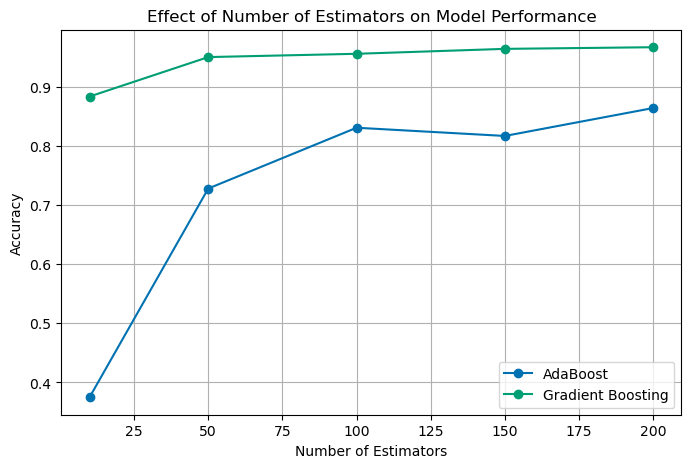

In [15]:
#plot the result
plt.figure(figsize=(8, 5))
plt.plot(estimators, ada_acc, marker='o', label='AdaBoost')
plt.plot(estimators, gb_acc, marker='o', label='Gradient Boosting')

plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Effect of Number of Estimators on Model Performance')
plt.legend()
plt.grid(True)

plt.savefig('estimators_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

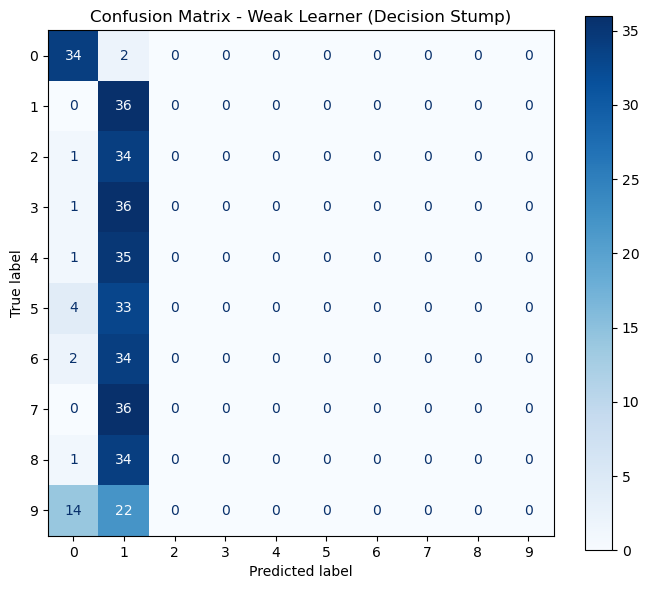

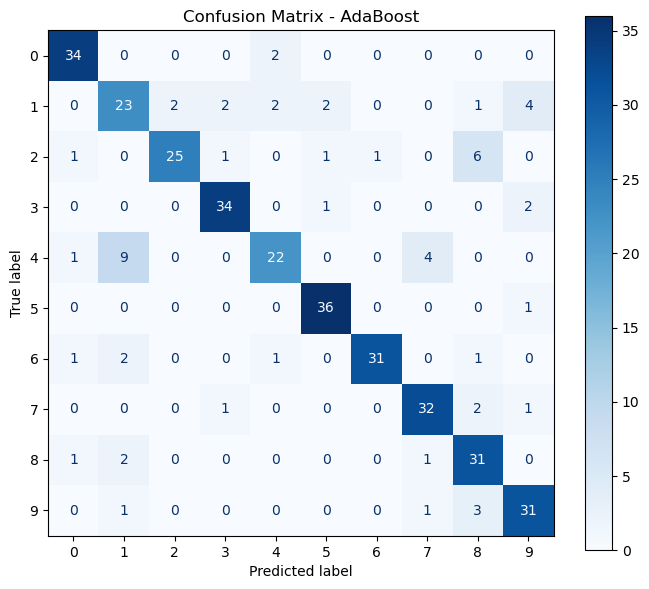

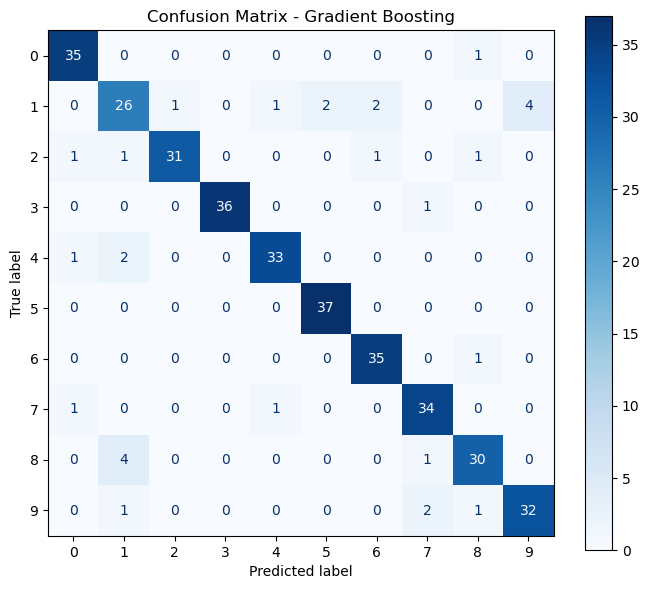

In [17]:
#13. Plot confusion matrices

models = [
    ("Weak Learner (Decision Stump)", y_pred_weak),
    ("AdaBoost", y_pred_ada),
    ("Gradient Boosting", y_pred_gb)
]

for model_name, preds in models:
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


Training vs Test Accuracy:
               Model  Training Accuracy  Test Accuracy
0       Weak Learner             0.1990         0.1944
1           AdaBoost             0.8608         0.8306
2  Gradient Boosting             0.9729         0.9139


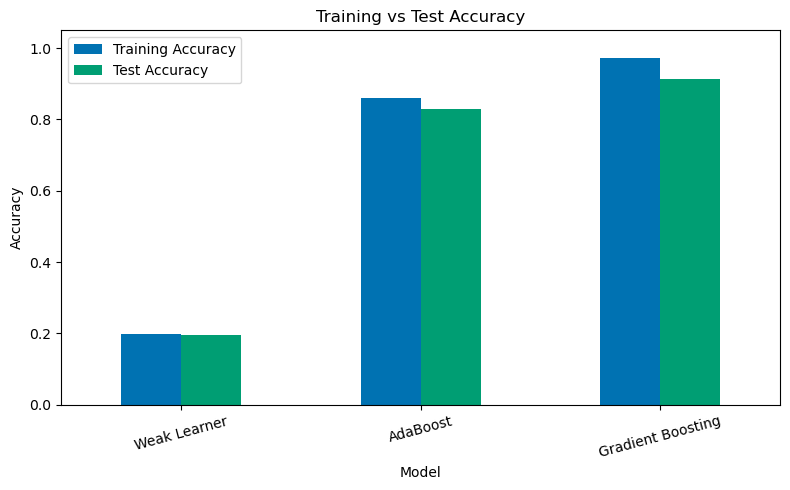

In [18]:
#14. Compare training vs test accuracy

train_scores = []
test_scores = []

# Weak learner
train_scores.append(accuracy_score(y_train, weak_learner.predict(X_train)))
test_scores.append(accuracy_score(y_test, y_pred_weak))

# AdaBoost
train_scores.append(accuracy_score(y_train, adaboost_model.predict(X_train)))
test_scores.append(accuracy_score(y_test, y_pred_ada))

# Gradient Boosting
train_scores.append(accuracy_score(y_train, gradient_boost_model.predict(X_train)))
test_scores.append(accuracy_score(y_test, y_pred_gb))

comparison_df = pd.DataFrame({
    "Model": ["Weak Learner", "AdaBoost", "Gradient Boosting"],
    "Training Accuracy": train_scores,
    "Test Accuracy": test_scores
})

print("\nTraining vs Test Accuracy:")
print(comparison_df.round(4))

ax = comparison_df.set_index("Model")[["Training Accuracy", "Test Accuracy"]].plot(kind="bar")
ax.set_title("Training vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()

# Save figure
plt.savefig("digits_training_vs_test_accuracy.png", dpi=300)
plt.show()


Feature importance table (first 5 rows):
   Feature  AdaBoost Importance  Gradient Boosting Importance
0  pixel_0             0.000000                      0.000000
1  pixel_1             0.000000                      0.000296
2  pixel_2             0.011816                      0.006776
3  pixel_3             0.000000                      0.010523
4  pixel_4             0.000000                      0.001431


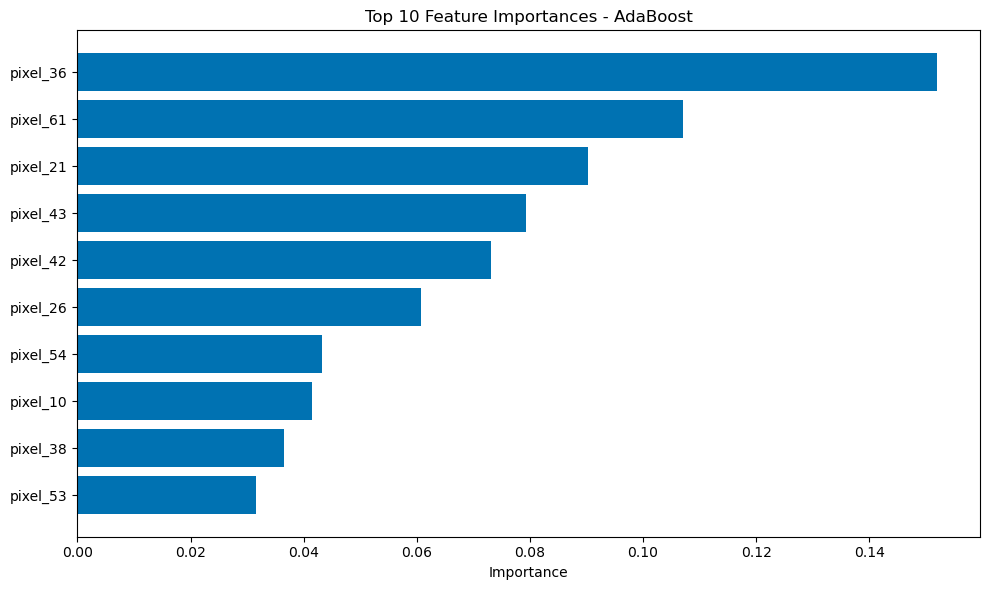

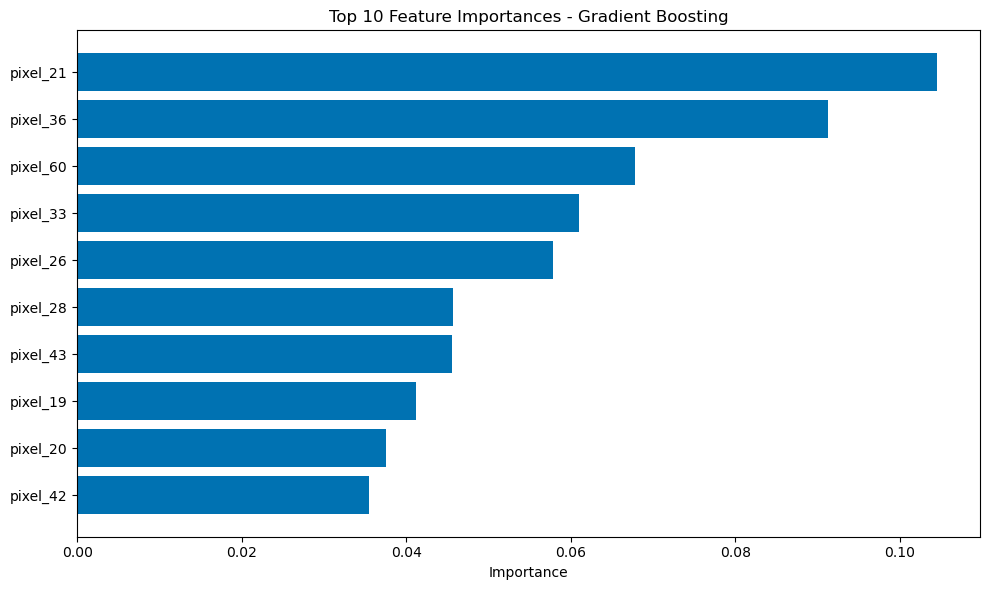

In [19]:
#15. Feature importance analysis

# For the digits dataset, each feature represents a pixel location
# in the 8*8 image. Feature importance therefore indicates
# which pixels are more influential for classification.
feature_importance_df = pd.DataFrame({
    "Feature": [f"pixel_{i}" for i in range(X.shape[1])],
    "AdaBoost Importance": adaboost_model.feature_importances_,
    "Gradient Boosting Importance": gradient_boost_model.feature_importances_
})

print("\nFeature importance table (first 5 rows):")
print(feature_importance_df.head())

# Top 10 AdaBoost feature importances
top_ada = feature_importance_df.sort_values(
    by="AdaBoost Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_ada["Feature"], top_ada["AdaBoost Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - AdaBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("digits_top10_feature_importance_adaboost.png", dpi=300)
plt.show()

# Top 10 Gradient Boosting feature importances
top_gb = feature_importance_df.sort_values(
    by="Gradient Boosting Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_gb["Feature"], top_gb["Gradient Boosting Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("digits_top10_feature_importance_gradient_boosting.png", dpi=300)
plt.show()



Best-performing model based on accuracy: Gradient Boosting
Number of misclassified test samples: 31


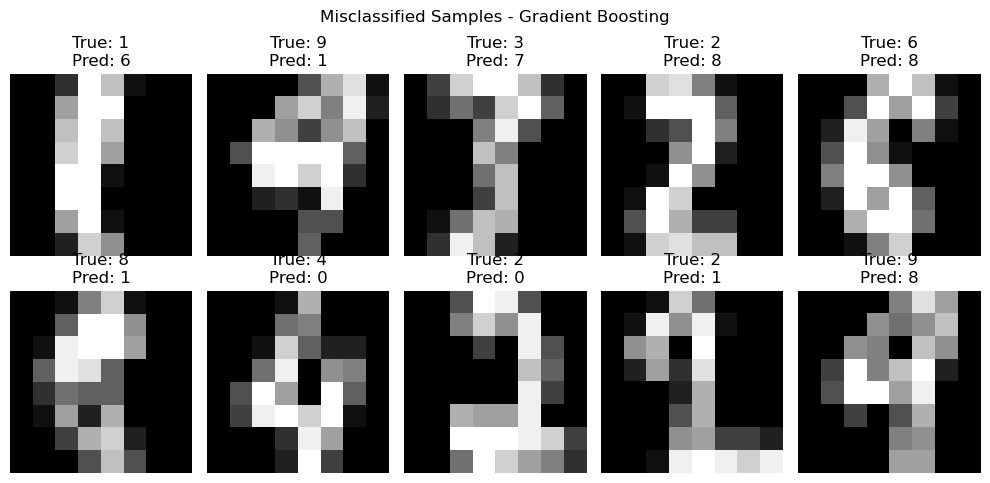

In [20]:
#16. Display some misclassified examples

best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]

if best_model_name == "Weak Learner (Decision Stump)":
    best_predictions = y_pred_weak
elif best_model_name == "AdaBoost":
    best_predictions = y_pred_ada
else:
    best_predictions = y_pred_gb

misclassified_indices = np.where(best_predictions != y_test)[0]

print(f"\nBest-performing model based on accuracy: {best_model_name}")
print(f"Number of misclassified test samples: {len(misclassified_indices)}")

# Show up to 10 misclassified samples
n_show = min(10, len(misclassified_indices))
if n_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_indices[:n_show]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
        ax.set_title(f"True: {y_test[idx]}\nPred: {best_predictions[idx]}")
        ax.axis("off")
    plt.suptitle(f"Misclassified Samples - {best_model_name}")
    plt.tight_layout()
    plt.show()


In [21]:
#17. Final Summary

final_results = results_df.copy()
final_results[["Accuracy", "Precision", "Recall", "F1-score"]] = final_results[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

print("\nFinal Summary Table:")
print(final_results)

best_model = final_results.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
print(f"\nThe best-performing model based on accuracy is: {best_model}")


Final Summary Table:
                           Model  Accuracy  Precision  Recall  F1-score
0  Weak Learner (Decision Stump)    0.1944     0.0705  0.1944    0.0936
1                       AdaBoost    0.8306     0.8367  0.8306    0.8291
2              Gradient Boosting    0.9139     0.9136  0.9139    0.9132

The best-performing model based on accuracy is: Gradient Boosting
